# 沿晶界 (GB) 氧化后处理 — 前沿时间演化与实验对照（Acta Materialia 绘图风格）

本 notebook 放在工作目录下运行，自动扫描内部的 `dose*` 子文件夹并读取其中的
`fields_timeseries.mat`（时间序列，模拟时间单位 **s**）与 `*_final.csv`（末时刻沿 GB 剖面）。

1. **Figure 1**：末时刻各氧化物（Cr$_2$O$_3$、Fe$_3$O$_4$、FeCr$_2$O$_4$、SiO$_2$）、总氧化物及 O 沿晶界剖面的不同 dose 对比（六面板，双栏 190 mm）；
2. **Figure 2**：**氧化前沿随时间的演化与实验数据对照**（每个 dose 单独一图，单栏 90 mm）；
   前沿定义为 **总氧化物厚度 = 1 nm**（`OX_TARGET`），模拟时间由 s 换算为 h 与实验一致；
3. **Figure 3**：全部 dose 的前沿时间演化合并对比图；
4. **Figure 4/5**：末时刻氧化前沿随 dose 变化，以及前沿位置在剖面上的标注（三种前沿定义）：
   - 定义 1：*总氧化物* 厚度 = 1 nm（与 Figure 2/3 一致，主定义）；
   - 定义 2：*Fe$_3$O$_4$* 厚度 = 1 nm；
   - 定义 3：*O 浓度* 等于阈值（Fe 氧化阈值，文献中内层氧化物尖端）的位置；
5. **Figure 6/7**：氧化物中各元素原子百分比；**Figure 8**：Ni 晶界峰值随 dose 变化。

所有阈值 / 文件名约定集中在下方第一个代码单元格（**修改窗口**）中，直接改后重跑即可。

**前沿的取法**：沿 GB 深度方向从开口 ($y=0$) 出发，取剖面**首次**跌破阈值处（线性插值到亚网格精度）。
剖面尾部因零通量边界会有轻微回升，故不能用「全域最接近阈值的点」，否则会跳到 GB 末端。

**实验数据**：工作目录下 `Oxidationfront_Time<dose>dpa.csv`，两列 `x, y` 分别为时间 (h) 与前沿深度 (nm)。

**网格**：$n_y$、$\Delta y$ 从 `fields_timeseries.mat` 的 `p` 结构读取，晶界总长 $L_{GB}=n_y\Delta y$（本文件夹为 150 nm）。

绘图规范（Acta Materialia / Elsevier）：
- 字体 Arial/Helvetica，正文 8 pt、轴标题 9 pt（缩印后不小于 7 pt）；
- 单栏宽 90 mm，双栏宽 190 mm；输出 600 dpi（线条图）+ 矢量 PDF（字体嵌入 TrueType, fonttype 42）；
- 数据线宽 1.2 pt，坐标轴线宽 0.8 pt，刻度朝内、四边镜像；
- 配色采用 Okabe–Ito 色盲友好色系（已通过 CVD 安全性验证），并辅以线型区分以保证黑白打印可辨。


In [25]:
# ==================== 修改窗口 (用户可调参数) ====================
OX_TARGET = 0.001    # 氧化物厚度前沿阈值 (nm): total oxide / Fe3O4 定义用 (主定义: total = 1 nm)
O_FRONT   = 0.012    # O 浓度前沿阈值 (归一化): 前沿 = O 浓度等于该值的位置
                     #   (Fe 氧化阈值, 文献中定义为内层氧化物尖端)

SEC_PER_HOUR = 3600.0                                  # 模拟时间 s -> 实验时间 h
EXP_FILE_FMT = 'Oxidationfront_Time{dose:g}dpa.csv'    # 实验前沿文件 (列: 时间 h, 前沿 nm)


In [26]:
import os, re, glob
import numpy as np
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---------------- Acta Materialia (Elsevier) 绘图规范 ----------------
MM = 1 / 25.4                 # mm -> inch
SINGLE_COL = 90 * MM          # 单栏 90 mm
DOUBLE_COL = 190 * MM         # 双栏 190 mm

ACTA_STYLE = {
    # 字体：Arial/Helvetica 无衬线，正文 8 pt，轴标题 9 pt
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'mathtext.fontset': 'dejavusans',
    # 线宽
    'lines.linewidth': 1.2,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.6,
    'ytick.minor.width': 0.6,
    'xtick.major.size': 3.5,
    'ytick.major.size': 3.5,
    'xtick.minor.size': 2.0,
    'ytick.minor.size': 2.0,
    # 刻度朝内，四边镜像
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    # 图例
    'legend.frameon': False,
    'legend.handlelength': 1.8,
    # 输出：600 dpi 线条图；PDF/PS 嵌入 TrueType 字体
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'figure.dpi': 130,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
}
mpl.rcParams.update(ACTA_STYLE)

# Okabe-Ito 色盲友好配色（dose 序列固定顺序分配，不循环）
DOSE_COLORS = ['#000000', '#0072B2', '#D55E00', '#E69F00', '#009E73', '#CC79A7', '#56B4E9']
DOSE_LS     = ['-', '--', '-.', ':', '-', '--', '-.']   # 线型作辅助编码，保证黑白打印可辨

OXIDES = ['Cr2O3', 'Fe3O4', 'FeCr2O4', 'SiO2']
LABELS = {'Cr2O3': r'Cr$_2$O$_3$', 'Fe3O4': r'Fe$_3$O$_4$',
          'FeCr2O4': r'FeCr$_2$O$_4$', 'SiO2': r'SiO$_2$',
          'total': 'Total oxide', 'O': 'O'}

ROOT = os.getcwd()            # notebook 位于 1/ 内
FIGDIR = os.path.join(ROOT, 'figures')
os.makedirs(FIGDIR, exist_ok=True)
print('工作目录:', ROOT)

工作目录: /Volumes/WZ_T9/RISconti/timedependent/20260831/1


In [27]:
# ---------------- 扫描 dose* 文件夹: 末时刻剖面 + 时间序列 + 实验前沿 ----------------
def dose_of(path):
    return float(re.findall(r'dose([\d.]+)', os.path.basename(path))[0])

dose_dirs = sorted(
    (d for d in glob.glob(os.path.join(ROOT, 'dose*'))
     if os.path.isdir(d) and not os.path.basename(d).startswith('._')),
    key=dose_of)
assert dose_dirs, '未找到 dose* 文件夹，请确认 notebook 位于工作目录下运行'

data = {}          # {dose: {'y','t', 各氧化物末剖面, 'total', 'O', '*_t' 时间序列}}
for d in dose_dirs:
    dose = dose_of(d)
    rec = {ox: np.loadtxt(os.path.join(d, f'{ox}_final.csv')) for ox in OXIDES}
    rec['O'] = np.loadtxt(os.path.join(d, 'O_final.csv'))
    rec['total'] = np.sum([rec[ox] for ox in OXIDES], axis=0)

    # 时间序列: *_t 为 (nt, ny), t_out 单位 s -> h; 网格 ny/dy 取自 p 结构
    with h5py.File(os.path.join(d, 'fields_timeseries.mat'), 'r') as h:
        ny = int(h['p']['ny'][0, 0]); dy = float(h['p']['dy'][0, 0])
        rec['t'] = np.array(h['t_out']).ravel() / SEC_PER_HOUR
        rec['oxi_time'] = float(h['p']['oxi_time'][0, 0]) / SEC_PER_HOUR
        for ox in OXIDES:
            rec[f'{ox}_t'] = np.array(h[f'{ox}_t'])
        rec['O_t'] = np.array(h['O_t'])
    rec['total_t'] = np.sum([rec[f'{ox}_t'] for ox in OXIDES], axis=0)
    rec['y'] = np.arange(ny) * dy          # 沿晶界深度坐标

    # 一致性检查: 时间序列末帧应与 *_final.csv 相同
    assert rec['total_t'].shape[1] == ny, f'{d}: 时间序列 ny 与网格不符'
    if not np.allclose(rec['total_t'][-1], rec['total'], rtol=1e-6, atol=1e-9):
        print(f'  ! 警告: {os.path.basename(d)} 时间序列末帧与 *_final.csv 不一致，'
              f'最大偏差 {np.abs(rec["total_t"][-1] - rec["total"]).max():.3g} nm')

    data[dose] = rec
    print(f'dose = {dose:g} dpa   ny = {ny}, dy = {dy:g} nm   '
          f'nt = {len(rec["t"])}, t = 0 ~ {rec["t"][-1]:g} h   '
          f'total oxide(末时刻): {rec["total"].min():.3g} ~ {rec["total"].max():.3g} nm')

doses = sorted(data)
L_GB = data[doses[0]]['y'][-1] + dy        # 晶界总长, 由数据网格决定
print(f'晶界总长 L_GB = {L_GB:g} nm')

# ---------------- 实验前沿数据 (时间 h, 前沿 nm) ----------------
exp = {}
for dose in doses:
    f = os.path.join(ROOT, EXP_FILE_FMT.format(dose=dose))
    if not os.path.isfile(f):
        print(f'  ! 未找到 {dose:g} dpa 的实验数据文件: {os.path.basename(f)}')
        continue
    arr = np.atleast_2d(np.loadtxt(f, delimiter=',', skiprows=1))
    exp[dose] = arr[np.argsort(arr[:, 0])]              # 按时间排序
    print(f'实验 {dose:g} dpa: {len(exp[dose])} 点, '
          f't = {exp[dose][0, 0]:g} ~ {exp[dose][-1, 0]:g} h, '
          f'前沿 = {exp[dose][0, 1]:g} ~ {exp[dose][-1, 1]:g} nm')


dose = 0.5 dpa   ny = 150, dy = 1 nm   nt = 101, t = 0 ~ 1500 h   total oxide(末时刻): 0.000106 ~ 22.8 nm
dose = 1.5 dpa   ny = 150, dy = 1 nm   nt = 101, t = 0 ~ 1500 h   total oxide(末时刻): 0.000107 ~ 20.8 nm
晶界总长 L_GB = 150 nm
实验 0.5 dpa: 5 点, t = 25.1418 ~ 1499.94 h, 前沿 = 47.2983 ~ 109.395 nm
实验 1.5 dpa: 5 点, t = 26.0214 ~ 1502.37 h, 前沿 = 56.3269 ~ 115.708 nm


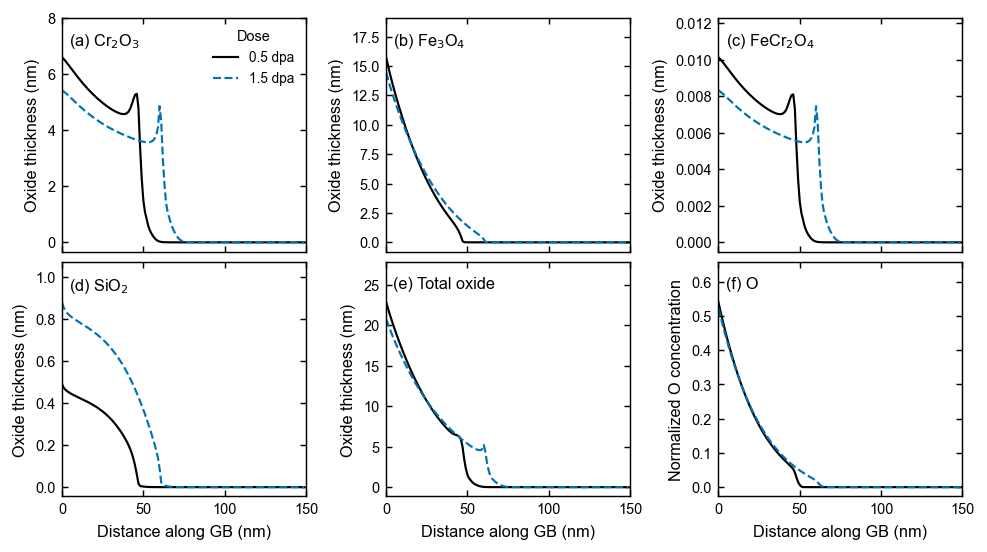

In [28]:
# ---------------- Figure 1: 各氧化物 / 总氧化物 / O 沿晶界剖面, 不同 dose 对比 ----------------
panels = OXIDES + ['total', 'O']

fig, axes = plt.subplots(2, 3, figsize=(DOUBLE_COL, 105 * MM),
                         sharex=True, constrained_layout=True)

for k, (key, ax) in enumerate(zip(panels, axes.flat)):
    for i, dose in enumerate(doses):
        rec = data[dose]
        ax.plot(rec['y'], rec[key], color=DOSE_COLORS[i], ls=DOSE_LS[i],
                label=f'{dose:g} dpa')
    ax.set_xlim(0, L_GB)
    y0, y1 = ax.get_ylim()                 # 顶部留白, 避免面板标签与曲线重叠
    ax.set_ylim(y0, y1 + 0.15 * (y1 - y0))
    ax.text(0.03, 0.94, f'({chr(97 + k)}) {LABELS[key]}',
            transform=ax.transAxes, ha='left', va='top', fontsize=9)
    if key == 'O':
        ax.set_ylabel('Normalized O concentration')
    else:
        ax.set_ylabel('Oxide thickness (nm)')
    if k >= 3:
        ax.set_xlabel('Distance along GB (nm)')

axes.flat[0].legend(loc='upper right', title='Dose')

for ext in ('pdf', 'png'):
    fig.savefig(os.path.join(FIGDIR, f'Fig1_oxide_profiles_along_GB.{ext}'))
plt.show()

## 氧化前沿随时间的演化 — 模拟 vs 实验

前沿定义：沿 GB 深度方向，**总氧化物厚度**（Cr$_2$O$_3$+Fe$_3$O$_4$+FeCr$_2$O$_4$+SiO$_2$ 等效厚度之和）
首次跌破 `OX_TARGET` = 1 nm 的深度，线性插值到亚网格精度。

- 模拟时间 `t_out` 由 s 换算为 h（$1\,\mathrm{h}=3600\,\mathrm{s}$），与实验时间轴一致；
- 前沿深度上限为晶界总长 $L_{GB}=150$ nm（若全域厚度均 $\ge$ 阈值则记为已穿透，取 $L_{GB}$）；
- **Figure 2**：每个 dose 单独一图（单栏 90 mm），实线为模拟、空心符号为实验；
- **Figure 3**：全部 dose 合并对比；
- 前沿-时间曲线同时存为 `figures/oxidation_front_vs_time.csv`，
  并按实验时间点插值给出偏差（MAE / RMSE）。


In [29]:
# ---------------- 氧化前沿提取 (通用) 与前沿-时间曲线 ----------------
def front_depth(y, prof, target, L=None):
    """氧化前沿深度: 沿深度方向自 GB 开口 (y=0) 起, 剖面首次跌破 target 的位置。

    剖面尾部受零通量边界影响会轻微回升, 因此取最靠近开口的下穿点并线性插值,
    而不是全域最接近 target 的网格点 (后者会跳到 GB 末端)。
      - 开口处即低于 target (尚未成膜) -> 0
      - 全域均 >= target (前沿已穿透 GB) -> L (默认 y[-1] + dy)
    """
    L = (y[-1] + (y[1] - y[0])) if L is None else L
    if prof[0] < target:
        return 0.0
    below = np.flatnonzero(prof < target)
    if below.size == 0:
        return L
    j = below[0]
    return y[j - 1] + (prof[j - 1] - target) / (prof[j - 1] - prof[j]) * (y[j] - y[j - 1])


FRONT_KEY = 'total'        # 主定义: 总氧化物厚度 = OX_TARGET
front_t = {}               # front_t[dose] = 前沿深度随时间 (nm)
for dose in doses:
    rec = data[dose]
    front_t[dose] = np.array([front_depth(rec['y'], p, OX_TARGET, L_GB)
                              for p in rec[f'{FRONT_KEY}_t']])
    sat = rec['t'][front_t[dose] >= L_GB - 1e-9]
    print(f'dose = {dose:g} dpa:  前沿 {front_t[dose][0]:.1f} nm (t=0) -> '
          f'{front_t[dose][-1]:.1f} nm (t={rec["t"][-1]:g} h)'
          + (f'   [t >= {sat[0]:g} h 已穿透 GB]' if sat.size else ''))

# --- 与实验对照: 把模拟前沿插值到实验时间点 ---
print()
for dose in doses:
    if dose not in exp:
        continue
    te, ye = exp[dose][:, 0], exp[dose][:, 1]
    ys = np.interp(te, data[dose]['t'], front_t[dose])
    err = ys - ye
    print(f'dose = {dose:g} dpa   MAE = {np.abs(err).mean():.2f} nm   '
          f'RMSE = {np.sqrt((err ** 2).mean()):.2f} nm')
    for a, b, c in zip(te, ye, ys):
        print(f'    t = {a:7.1f} h:  实验 {b:6.2f} nm   模拟 {c:6.2f} nm   偏差 {c - b:+6.2f} nm')

# --- 保存前沿-时间曲线 (各 dose 时间网格一致时合并为一张表) ---
same_t = all(np.array_equal(data[d]['t'], data[doses[0]]['t']) for d in doses)
if same_t:
    out = np.column_stack([data[doses[0]]['t']] + [front_t[d] for d in doses])
    hdr = 'time_h,' + ','.join(f'front_nm_dose{d:g}dpa' for d in doses)
    np.savetxt(os.path.join(FIGDIR, 'oxidation_front_vs_time.csv'), out,
               delimiter=',', header=hdr, comments='', fmt='%.6g')
else:
    for d in doses:
        np.savetxt(os.path.join(FIGDIR, f'oxidation_front_vs_time_dose{d:g}dpa.csv'),
                   np.column_stack([data[d]['t'], front_t[d]]), delimiter=',',
                   header='time_h,front_nm', comments='', fmt='%.6g')


dose = 0.5 dpa:  前沿 0.0 nm (t=0) -> 65.9 nm (t=1500 h)
dose = 1.5 dpa:  前沿 0.0 nm (t=0) -> 81.4 nm (t=1500 h)

dose = 0.5 dpa   MAE = 19.02 nm   RMSE = 24.40 nm
    t =    25.1 h:  实验  47.30 nm   模拟  64.67 nm   偏差 +17.38 nm
    t =    98.5 h:  实验  64.13 nm   模拟  65.57 nm   偏差  +1.44 nm
    t =   501.7 h:  实验  71.00 nm   模拟  65.64 nm   偏差  -5.35 nm
    t =   999.8 h:  实验  93.25 nm   模拟  65.77 nm   偏差 -27.48 nm
    t =  1499.9 h:  实验 109.40 nm   模拟  65.93 nm   偏差 -43.47 nm
dose = 1.5 dpa   MAE = 18.82 nm   RMSE = 22.21 nm
    t =    26.0 h:  实验  56.33 nm   模拟  76.85 nm   偏差 +20.53 nm
    t =   101.3 h:  实验  77.62 nm   模拟  80.82 nm   偏差  +3.20 nm
    t =   502.9 h:  实验  88.93 nm   模拟  81.10 nm   偏差  -7.83 nm
    t =  1004.6 h:  实验 109.48 nm   模拟  81.26 nm   偏差 -28.23 nm
    t =  1502.4 h:  实验 115.71 nm   模拟  81.39 nm   偏差 -34.31 nm


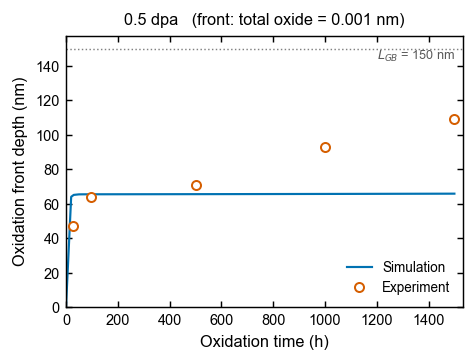

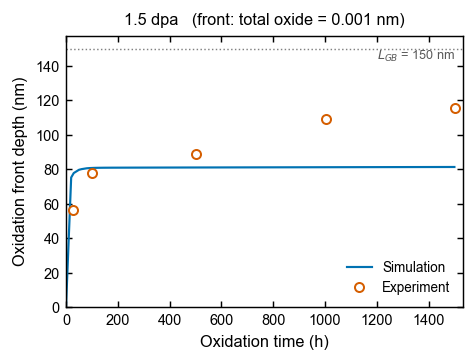

In [30]:
# ---------------- Figure 2: 前沿随时间演化, 每个 dose 单独成图 (模拟 vs 实验) ----------------
SIM_C, EXP_C = '#0072B2', '#D55E00'        # Okabe-Ito: 蓝 = 模拟, 橙红 = 实验
T_MAX = max([data[d]['t'][-1] for d in doses] +
            [exp[d][-1, 0] for d in doses if d in exp])

for dose in doses:
    rec = data[dose]
    fig, ax = plt.subplots(figsize=(SINGLE_COL, 68 * MM), constrained_layout=True)

    ax.plot(rec['t'], front_t[dose], '-', color=SIM_C, label='Simulation')
    if dose in exp:
        ax.plot(exp[dose][:, 0], exp[dose][:, 1], ls='none', marker='o', ms=5,
                mfc='white', mec=EXP_C, mew=1.1, label='Experiment', clip_on=False)

    ax.axhline(L_GB, color='0.5', lw=0.8, ls=':', zorder=0)      # GB 总长参考线
    ax.text(0.98, L_GB, f'$L_{{GB}}$ = {L_GB:g} nm', transform=ax.get_yaxis_transform(),
            ha='right', va='top', fontsize=7, color='0.35')

    ax.set_xlabel('Oxidation time (h)')
    ax.set_ylabel('Oxidation front depth (nm)')
    ax.set_xlim(0, T_MAX * 1.02)
    ax.set_ylim(0, L_GB * 1.05)
    ax.set_title(f'{dose:g} dpa   (front: total oxide = {OX_TARGET:g} nm)', fontsize=9)
    ax.legend(loc='lower right')

    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(FIGDIR, f'Fig2_front_vs_time_dose{dose:g}dpa.{ext}'))
    plt.show()


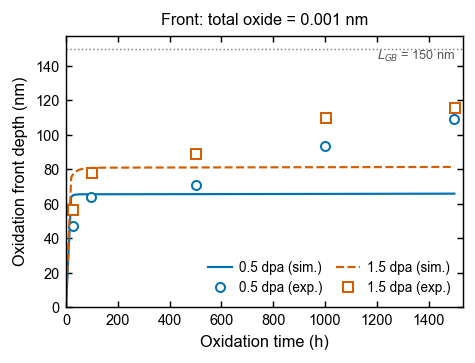

In [31]:
# ---------------- Figure 3: 全部 dose 的前沿时间演化合并对比 ----------------
fig, ax = plt.subplots(figsize=(SINGLE_COL, 68 * MM), constrained_layout=True)

for i, dose in enumerate(doses):
    c = DOSE_COLORS[i + 1]                                   # 跳过纯黑, 与实验符号区分
    ax.plot(data[dose]['t'], front_t[dose], ls=DOSE_LS[i], color=c,
            label=f'{dose:g} dpa (sim.)')
    if dose in exp:
        ax.plot(exp[dose][:, 0], exp[dose][:, 1], ls='none', marker='os^Dv'[i], ms=5,
                mfc='white', mec=c, mew=1.1, label=f'{dose:g} dpa (exp.)', clip_on=False)

ax.axhline(L_GB, color='0.5', lw=0.8, ls=':', zorder=0)
ax.text(0.98, L_GB, f'$L_{{GB}}$ = {L_GB:g} nm', transform=ax.get_yaxis_transform(),
        ha='right', va='top', fontsize=7, color='0.35')

ax.set_xlabel('Oxidation time (h)')
ax.set_ylabel('Oxidation front depth (nm)')
ax.set_xlim(0, T_MAX * 1.02)
ax.set_ylim(0, L_GB * 1.05)
ax.set_title(f'Front: total oxide = {OX_TARGET:g} nm', fontsize=9)
ax.legend(loc='lower right', ncol=len(doses), columnspacing=1.0, handletextpad=0.5)

for ext in ('pdf', 'png'):
    fig.savefig(os.path.join(FIGDIR, f'Fig3_front_vs_time_all_doses.{ext}'))
plt.show()


In [32]:
# ---------------- 末时刻氧化前沿: 三种定义 ----------------
#  定义 1: 总氧化物厚度 = OX_TARGET (默认 1 nm)  —— 与 Figure 2/3 一致
#  定义 2: Fe3O4 厚度 = OX_TARGET
#  定义 3: O 浓度 = O_FRONT (Fe 氧化阈值) —— 内层氧化物尖端
FRONT_KEYS    = ['total', 'Fe3O4', 'O']
FRONT_TARGETS = {'total': OX_TARGET, 'Fe3O4': OX_TARGET, 'O': O_FRONT}

front = {k: {} for k in FRONT_KEYS}        # front[key][dose] = 末时刻前沿深度 (nm)
for key in FRONT_KEYS:
    tgt = FRONT_TARGETS[key]
    for dose in doses:
        rec = data[dose]
        front[key][dose] = front_depth(rec['y'], rec[key], tgt, L_GB)
        print(f'[{key:>5s} = {tgt:g}]  dose = {dose:g} dpa:  '
              f'末时刻前沿 = {front[key][dose]:.2f} nm')
    print()

# 保存末时刻前沿数据
out = np.array([[d] + [front[k][d] for k in FRONT_KEYS] for d in doses])
np.savetxt(os.path.join(FIGDIR, 'oxidation_front_vs_dose.csv'), out, delimiter=',',
           header='dose_dpa,' + ','.join(f'{k}_front_nm' for k in FRONT_KEYS),
           comments='', fmt='%.4g')


[total = 0.001]  dose = 0.5 dpa:  末时刻前沿 = 65.93 nm
[total = 0.001]  dose = 1.5 dpa:  末时刻前沿 = 81.39 nm

[Fe3O4 = 0.001]  dose = 0.5 dpa:  末时刻前沿 = 51.75 nm
[Fe3O4 = 0.001]  dose = 1.5 dpa:  末时刻前沿 = 66.08 nm

[    O = 0.012]  dose = 0.5 dpa:  末时刻前沿 = 49.30 nm
[    O = 0.012]  dose = 1.5 dpa:  末时刻前沿 = 61.37 nm



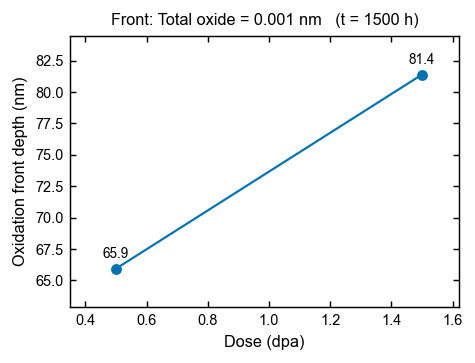

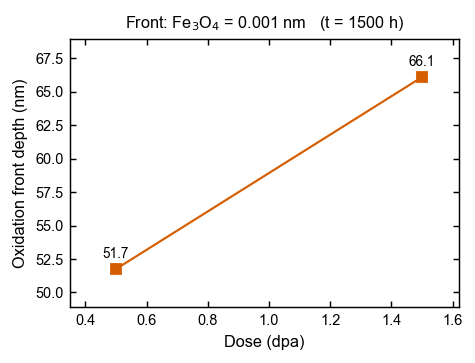

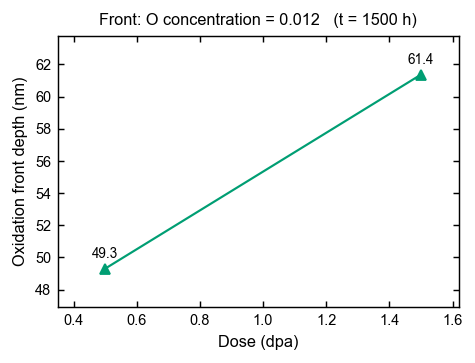

In [33]:
# ---------------- Figure 4: 末时刻氧化前沿深度随 dose 变化 (三种定义分别成图) ----------------
FRONT_STYLE = {'total': dict(color='#0072B2', marker='o', tag='total_oxide',
                             title=f'Total oxide = {OX_TARGET:g} nm', fmt='{:.1f}'),
               'Fe3O4': dict(color='#D55E00', marker='s', tag='Fe3O4',
                             title=rf'Fe$_3$O$_4$ = {OX_TARGET:g} nm', fmt='{:.1f}'),
               'O':     dict(color='#009E73', marker='^', tag='O_conc',
                             title=f'O concentration = {O_FRONT:g}', fmt='{:.1f}')}

x = np.array(doses)
for key in FRONT_KEYS:
    st = FRONT_STYLE[key]
    fig, ax = plt.subplots(figsize=(SINGLE_COL, 68 * MM), constrained_layout=True)

    yf = np.array([front[key][d] for d in doses])
    ax.plot(x, yf, ls='-', marker=st['marker'], color=st['color'],
            markersize=5, clip_on=False)
    for xi, yi in zip(x, yf):                      # 选择性直接标注数据点
        ax.annotate(st['fmt'].format(yi), (xi, yi), textcoords='offset points',
                    xytext=(0, 6), ha='center', fontsize=7.5)

    ax.set_xlabel('Dose (dpa)')
    ax.set_ylabel('Oxidation front depth (nm)')
    ax.set_xlim(min(x) - 0.15, max(x) * 1.08)
    pad = max(1.0, 0.2 * (yf.max() - yf.min()))    # 数据自适应 y 范围, 避免趋势被压平
    ax.set_ylim(yf.min() - pad, yf.max() + pad)
    ax.set_title(f'Front: {st["title"]}   (t = {data[doses[0]]["t"][-1]:g} h)', fontsize=9)

    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(FIGDIR, f'Fig4_front_{st["tag"]}_vs_dose.{ext}'))
    plt.show()


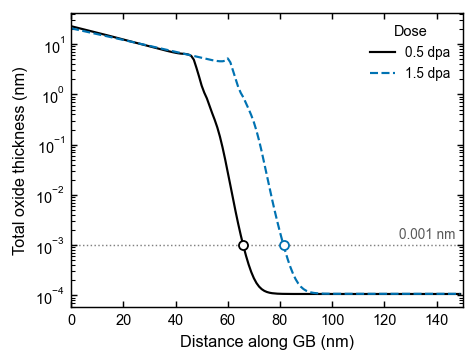

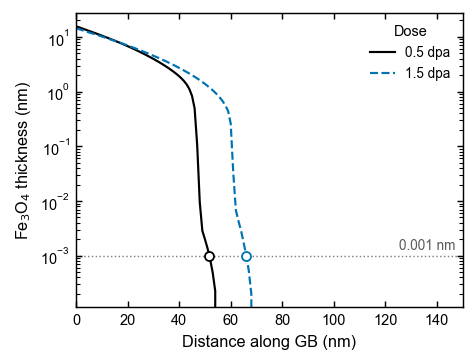

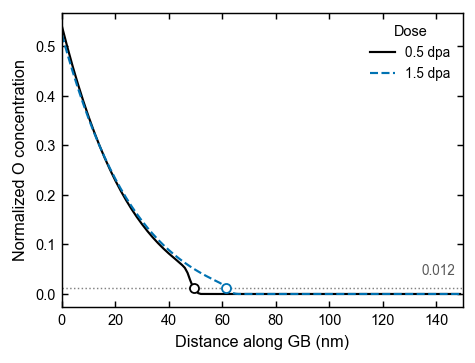

In [34]:
# ---------------- Figure 5: 末时刻剖面上标注前沿位置 (三种定义分别成图) ----------------
YLAB = {'total': 'Total oxide thickness (nm)',
        'Fe3O4': r'Fe$_3$O$_4$ thickness (nm)',
        'O':     'Normalized O concentration'}
for key in FRONT_KEYS:
    st, tgt = FRONT_STYLE[key], FRONT_TARGETS[key]
    fig, ax = plt.subplots(figsize=(SINGLE_COL, 68 * MM), constrained_layout=True)

    for i, dose in enumerate(doses):
        rec = data[dose]
        ax.plot(rec['y'], rec[key], color=DOSE_COLORS[i], ls=DOSE_LS[i],
                label=f'{dose:g} dpa')
        yi = front[key][dose]
        vi = np.interp(yi, rec['y'], rec[key])
        ax.plot(yi, vi, 'o', ms=5, mfc='white', mec=DOSE_COLORS[i],
                mew=1.0, zorder=5)
    ax.axhline(tgt, color='0.5', lw=0.8, ls=':', zorder=0)
    unit = ' nm' if key != 'O' else ''
    if key == 'O':                         # O 浓度按用户要求用线性轴
        ax.text(0.98 * L_GB, tgt + 0.02, f'{tgt:g}{unit}', ha='right', va='bottom',
                fontsize=7.5, color='0.35')
    else:
        ax.set_yscale('log')               # 厚度剖面跨量级, 对数轴便于看交点
        ax.text(0.98 * L_GB, tgt * 1.15, f'{tgt:g}{unit}', ha='right', va='bottom',
                fontsize=7.5, color='0.35')
    ax.set_xlim(0, L_GB)
    ax.set_xlabel('Distance along GB (nm)')
    ax.set_ylabel(YLAB[key])
    ax.legend(loc='upper right', title='Dose')

    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(FIGDIR, f'Fig5_front_marked_{st["tag"]}.{ext}'))
    plt.show()


## 氧化物元素原子百分比（由等效厚度换算）

将各氧化物等效厚度 $t_{ox}$ 换算为单位面积摩尔数 $n_{ox}=t_{ox}/V_{m,ox}$（摩尔体积 $V_m=M/\rho$，取室温块体值），再按化学计量数汇总各元素原子数：
Cr$_2$O$_3$ → 2 Cr + 3 O；Fe$_3$O$_4$ → 3 Fe + 4 O；FeCr$_2$O$_4$ → 1 Fe + 2 Cr + 4 O；SiO$_2$ → 1 Si + 2 O。

- **Figure 6**：沿晶界各点氧化物的**局部**原子百分比（四面板 Fe/Cr/Si/O，不同 dose 对比；总氧化物 < 0.05 nm 的点视为噪声不显示）；
- **Figure 7**：**整个 GB** 氧化物积分后的总体原子百分比随 dose 变化；数据同时存为 `figures/GB_oxide_atomic_percent_vs_dose.csv`。


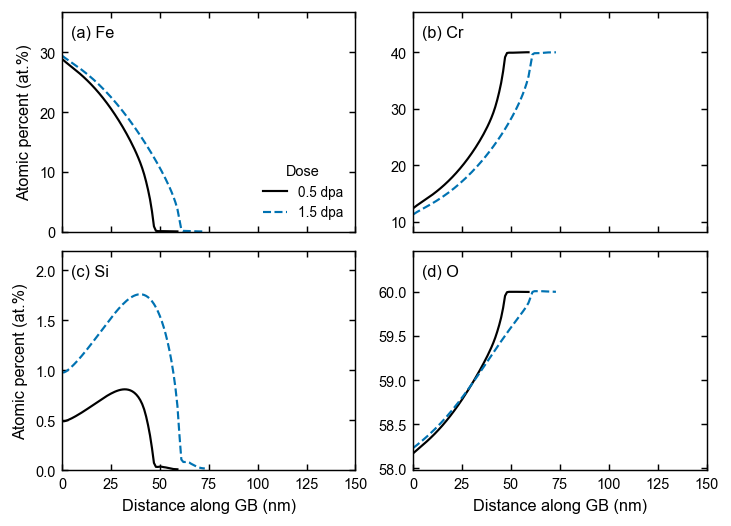

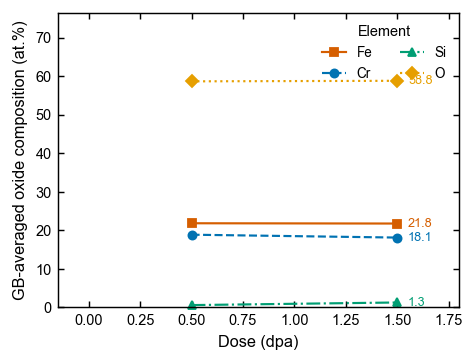

dose = 0.5 dpa: Fe = 21.85 at.%   Cr = 18.88 at.%   Si = 0.61 at.%   O = 58.66 at.%
dose = 1.5 dpa: Fe = 21.77 at.%   Cr = 18.13 at.%   Si = 1.29 at.%   O = 58.81 at.%


In [35]:
# ---------------- Figure 6/7: 氧化物中各元素的原子百分比 ----------------
# 厚度 -> 原子数: n_ox = t_ox / Vm_ox (单位面积摩尔数), 元素原子数 = Σ_ox n_ox × 化学计量数
OXIDE_PROPS = {'Cr2O3':   (151.99, 5.22),      # (摩尔质量 g/mol, 密度 g/cm3)
               'Fe3O4':   (231.53, 5.18),
               'FeCr2O4': (223.84, 5.09),
               'SiO2':    (60.08,  2.20)}      # 非晶 SiO2
STOICH = {'Cr2O3':   {'Cr': 2, 'O': 3},
          'Fe3O4':   {'Fe': 3, 'O': 4},
          'FeCr2O4': {'Fe': 1, 'Cr': 2, 'O': 4},
          'SiO2':    {'Si': 1, 'O': 2}}
ELEMENTS = ['Fe', 'Cr', 'Si', 'O']
VM = {ox: M / rho for ox, (M, rho) in OXIDE_PROPS.items()}   # 摩尔体积 cm3/mol
ATP_OX_MIN = 0.05        # nm: 局部成分只在总氧化物厚度超过该值处显示 (排除噪声尾部)

# 元素配色: Okabe-Ito 子集 (CVD 安全性已验证), 线型/标记作辅助编码
EL_COLORS  = {'Fe': '#D55E00', 'Cr': '#0072B2', 'Si': '#009E73', 'O': '#E69F00'}
EL_MARKERS = {'Fe': 's', 'Cr': 'o', 'Si': '^', 'O': 'D'}
EL_LS      = {'Fe': '-', 'Cr': '--', 'Si': '-.', 'O': ':'}

atp_local = {}    # atp_local[dose][el]: 沿 GB 的局部 at.% (噪声区为 NaN)
atp_gb = {}       # atp_gb[dose][el]:   整个 GB 积分后的总体 at.%
for dose in doses:
    rec = data[dose]
    n_el = {el: np.zeros_like(rec['total']) for el in ELEMENTS}
    for ox in OXIDES:
        for el, k in STOICH[ox].items():
            n_el[el] += rec[ox] / VM[ox] * k
    n_tot = np.sum([n_el[el] for el in ELEMENTS], axis=0)
    valid = rec['total'] >= ATP_OX_MIN
    atp_local[dose] = {el: np.where(valid & (n_tot > 0), 100 * n_el[el] / n_tot, np.nan)
                       for el in ELEMENTS}
    atp_gb[dose] = {el: 100 * n_el[el].sum() / n_tot.sum() for el in ELEMENTS}

# --- Figure 6: 局部原子百分比沿 GB 分布 (面板 = 元素, 曲线 = dose) ---
fig, axes = plt.subplots(2, 2, figsize=(140 * MM, 100 * MM),
                         sharex=True, constrained_layout=True)
for k, (el, ax) in enumerate(zip(ELEMENTS, axes.flat)):
    for i, dose in enumerate(doses):
        ax.plot(data[dose]['y'], atp_local[dose][el],
                color=DOSE_COLORS[i], ls=DOSE_LS[i], label=f'{dose:g} dpa')
    ax.set_xlim(0, L_GB)
    y0, y1 = ax.get_ylim()
    ax.set_ylim(max(0.0, y0 - 0.05 * (y1 - y0)), y1 + 0.18 * (y1 - y0))
    ax.text(0.03, 0.94, f'({chr(97 + k)}) {el}', transform=ax.transAxes,
            ha='left', va='top', fontsize=9)
    if k % 2 == 0:
        ax.set_ylabel('Atomic percent (at.%)')
    if k >= 2:
        ax.set_xlabel('Distance along GB (nm)')
axes.flat[0].legend(loc='lower right', title='Dose')

for ext in ('pdf', 'png'):
    fig.savefig(os.path.join(FIGDIR, f'Fig6_oxide_atomic_percent_along_GB.{ext}'))
plt.show()

# --- Figure 7: 整个 GB 总体原子百分比随 dose 变化 ---
xd = np.array(doses)
fig, ax = plt.subplots(figsize=(SINGLE_COL, 68 * MM), constrained_layout=True)
ymax = 0.0
for el in ELEMENTS:
    yv = np.array([atp_gb[d][el] for d in doses])
    ymax = max(ymax, yv.max())
    ax.plot(xd, yv, ls=EL_LS[el], marker=EL_MARKERS[el], color=EL_COLORS[el],
            markersize=4.5, label=el, clip_on=False)
    ax.annotate(f'{yv[-1]:.1f}', (xd[-1], yv[-1]),   # 仅末端数值直标, 全部数值见 CSV
                textcoords='offset points', xytext=(6, 0), ha='left', va='center',
                fontsize=7, color=EL_COLORS[el])
ax.set_xlabel('Dose (dpa)')
ax.set_ylabel('GB-averaged oxide composition (at.%)')
ax.set_xlim(-0.15, max(xd) * 1.2)
ax.set_ylim(0, ymax * 1.3)
ax.legend(loc='upper right', ncol=2, title='Element')

for ext in ('pdf', 'png'):
    fig.savefig(os.path.join(FIGDIR, f'Fig7_GB_atomic_percent_vs_dose.{ext}'))
plt.show()

# 保存整个 GB 的总体成分
out = np.array([[d] + [atp_gb[d][el] for el in ELEMENTS] for d in doses])
np.savetxt(os.path.join(FIGDIR, 'GB_oxide_atomic_percent_vs_dose.csv'), out,
           delimiter=',',
           header='dose_dpa,' + ','.join(f'{el}_at_pct' for el in ELEMENTS),
           comments='', fmt='%.4g')
for d in doses:
    print(f'dose = {d:g} dpa: ' +
          '   '.join(f'{el} = {atp_gb[d][el]:.2f} at.%' for el in ELEMENTS))


## Ni 晶界剖面峰值随 dose 的变化

`Ni_final.csv` / `Ni_irrfinal.csv` 为 ($n_y \times n_x$) 二维浓度场，GB 面位于 $x$ 第 0 列；
取该列得到 Ni 沿晶界的剖面，其最大值即 RIS 引起的 Ni 晶界偏聚峰。

- **Figure 8**：辐照后 (irr) 与氧化后 (oxi) 两阶段的 Ni GB 峰值浓度随 dose 变化；
  峰值大小与峰位置同时存为 `figures/Ni_GB_peak_vs_dose.csv`。


[irr] dose = 0.5 dpa:  Ni 峰值 = 0.2105  @ y = 98 nm
[oxi] dose = 0.5 dpa:  Ni 峰值 = 0.3019  @ y = 0 nm
[irr] dose = 1.5 dpa:  Ni 峰值 = 0.2545  @ y = 67 nm
[oxi] dose = 1.5 dpa:  Ni 峰值 = 0.3280  @ y = 0 nm


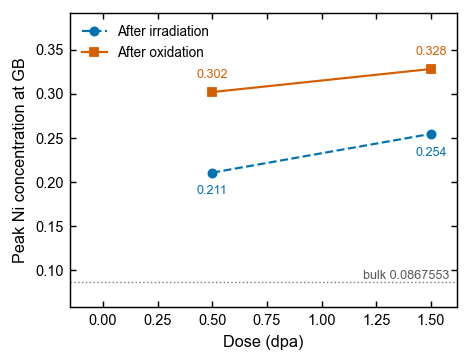

In [36]:
# ---------------- Figure 8: Ni GB 剖面峰值随 dose 变化 ----------------
# Ni_*.csv 为 (ny, nx) 二维场, GB 面在 x 第 0 列; GB 剖面 = 该列, 峰值 = 剖面最大值
NI_STAGES = {'irr': ('Ni_irrfinal.csv', 'After irradiation', '#0072B2', 'o', '--'),
             'oxi': ('Ni_final.csv',    'After oxidation',   '#D55E00', 's', '-')}

ni_peak = {st: {} for st in NI_STAGES}       # ni_peak[stage][dose] = (峰值, 峰位置 nm)
for dose in doses:
    ddir = os.path.join(ROOT, f'dose{dose:g}')
    for st, (fname, *_) in NI_STAGES.items():
        prof = np.loadtxt(os.path.join(ddir, fname), delimiter=',')[:, 0]  # GB 面剖面
        k = int(np.argmax(prof))
        ni_peak[st][dose] = (prof[k], data[dose]['y'][k])
        print(f'[{st}] dose = {dose:g} dpa:  Ni 峰值 = {prof[k]:.4f}  @ y = {data[dose]["y"][k]:g} nm')

ni_bulk = float(np.median(np.loadtxt(os.path.join(
    ROOT, f'dose{doses[0]:g}', 'Ni_irrfinal.csv'), delimiter=',')))   # 基体 Ni 浓度参考线

xd = np.array(doses)
fig, ax = plt.subplots(figsize=(SINGLE_COL, 68 * MM), constrained_layout=True)
peak_vals = {st: np.array([ni_peak[st][d][0] for d in doses]) for st in NI_STAGES}
for st, (fname, lab, color, marker, ls) in NI_STAGES.items():
    yv, other = peak_vals[st], peak_vals['oxi' if st == 'irr' else 'irr']
    ax.plot(xd, yv, ls=ls, marker=marker, color=color, markersize=4.5,
            label=lab, clip_on=False)
    for xi, yi, yo in zip(xd, yv, other):
        dy = 6 if yi >= yo else -7             # 两系列中较高的点标上方, 较低的标下方
        ax.annotate(f'{yi:.3f}', (xi, yi), textcoords='offset points',
                    xytext=(0, dy), va='bottom' if dy > 0 else 'top',
                    ha='center', fontsize=7, color=color)
ax.axhline(ni_bulk, color='0.5', lw=0.8, ls=':', zorder=0)
ax.text(0.98, ni_bulk, f'bulk {ni_bulk:g}', transform=ax.get_yaxis_transform(),
        ha='right', va='bottom', fontsize=7, color='0.35')
ax.set_xlabel('Dose (dpa)')
ax.set_ylabel('Peak Ni concentration at GB')
ax.set_xlim(-0.15, max(xd) * 1.08)
y_all = [ni_peak[st][d][0] for st in NI_STAGES for d in doses] + [ni_bulk]
pad = 0.12 * (max(y_all) - min(y_all))
ax.set_ylim(min(y_all) - pad, max(y_all) + 2.2 * pad)   # 顶部多留白放图例
ax.legend(loc='upper left')

for ext in ('pdf', 'png'):
    fig.savefig(os.path.join(FIGDIR, f'Fig8_Ni_GB_peak_vs_dose.{ext}'))
plt.show()

out = np.array([[d] + [v for st in NI_STAGES for v in ni_peak[st][d]] for d in doses])
np.savetxt(os.path.join(FIGDIR, 'Ni_GB_peak_vs_dose.csv'), out, delimiter=',',
           header='dose_dpa,' + ','.join(f'{st}_peak,{st}_peak_y_nm' for st in NI_STAGES),
           comments='', fmt='%.4g')
